# MIT-BIH Dataset Exploration

This notebook presents the locked Stage 1 dataset audit and exploratory analysis. No model is trained and no downstream scientific decision is changed.

## 1. Setup

Import the existing project libraries, set the fixed seed, and define repository-relative paths.

In [1]:
print(sys.executable)

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wfdb

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW = ROOT / "data" / "raw" / "mitdb"
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "figures"

PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)



## 2. Locate and Verify Dataset

Read the official record list and confirm that all 48 primary MIT-BIH records are present.

In [3]:
record_lines = (RAW / "RECORDS").read_text().splitlines()
records = [line.strip() for line in record_lines if line.strip().isdigit()]

assert len(records) == 48, f"Expected 48 primary records, found {len(records)}"
print(f"Python {sys.version.split()[0]} | wfdb {wfdb.__version__} | records {len(records)}")


Python 3.13.2 | wfdb 4.3.1 | records 48


## 3. Inspect One ECG Record

Inspect record 100 before running the full audit so the WFDB signal and annotation structure is clear.

In [4]:
example_record = wfdb.rdrecord(str(RAW / '100'))
example_annotation = wfdb.rdann(str(RAW / '100'), 'atr')
record_overview = pd.DataFrame({
    'Attribute': ['Record', 'Sampling frequency (Hz)', 'Channels', 'Signal shape', 'Annotation count'],
    'Value': ['100', example_record.fs, ', '.join(example_record.sig_name), str(example_record.p_signal.shape), len(example_annotation.sample)],
})
display(record_overview)

,Attribute,Value
0,Record,100
1,Sampling frequency (Hz),360
2,Channels,"MLII, V5"
3,Signal shape,"(650000, 2)"
4,Annotation count,2274


## 4. Audit All Records

Load every signal and annotation file, retain provenance, and verify sampling rate and signal integrity.

In [5]:
# Fixed mapping used throughout the project; changing it would change the experiment.
AAMI_MAP = {
    "N": "N", "L": "N", "R": "N", "e": "N", "j": "N",
    "A": "S", "a": "S", "J": "S", "S": "S",
    "V": "V", "E": "V",
    "F": "F",
    "/": "Q", "f": "Q", "Q": "Q", "?": "Q",
}
FINAL_CLASSES = ["N", "S", "V", "F"]
BEAT_SYMBOLS = set(AAMI_MAP)

audit_rows = []
annotation_rows = []
channel_rows = []
failures = []
headers = {}
annotations = {}

for record_id in records:
    try:
        record = wfdb.rdrecord(str(RAW / record_id))
        annotation = wfdb.rdann(str(RAW / record_id), "atr")
        headers[record_id] = record
        annotations[record_id] = annotation

        signal = record.p_signal
        audit_rows.append({
            "record_id": record_id,
            "n_channels": record.n_sig,
            "channel_names": "|".join(record.sig_name),
            "fs_hz": record.fs,
            "n_samples": record.sig_len,
            "duration_minutes": record.sig_len / record.fs / 60,
            "annotation_count": len(annotation.sample),
            "annotation_symbols": "".join(sorted(set(annotation.symbol))),
            "nan_count": int(np.isnan(signal).sum()),
            "infinite_count": int(np.isinf(signal).sum()),
            "minimum_mV": float(np.nanmin(signal)),
            "maximum_mV": float(np.nanmax(signal)),
            "mean_mV": float(np.nanmean(signal)),
            "std_mV": float(np.nanstd(signal)),
        })

        for channel_index, lead in enumerate(record.sig_name):
            channel_rows.append({
                "record_id": record_id,
                "channel_index": channel_index,
                "lead": lead,
            })

        for sample, symbol in zip(annotation.sample, annotation.symbol):
            annotation_rows.append({
                "record_id": record_id,
                "sample": int(sample),
                "symbol": symbol,
                "is_heartbeat": symbol in BEAT_SYMBOLS,
                "mapped_class": AAMI_MAP.get(symbol),
            })
    except Exception as exc:
        failures.append({"record_id": record_id, "error": repr(exc)})

audit = pd.DataFrame(audit_rows)
channel_detail = pd.DataFrame(channel_rows)
annotation_detail = pd.DataFrame(annotation_rows)

assert not failures
assert len(audit) == 48
assert audit["fs_hz"].eq(360).all()
assert audit[["nan_count", "infinite_count"]].to_numpy().sum() == 0

audit.to_csv(PROCESSED / "record_audit.csv", index=False)
display(audit)
print("Failures:", failures)


,record_id,n_channels,channel_names,fs_hz,n_samples,duration_minutes,annotation_count,annotation_symbols,nan_count,infinite_count,minimum_mV,maximum_mV,mean_mV,std_mV
0,100,2,MLII|V5,360,650000,30.092593,2274,+ANV,0,0,-2.715,1.435,-0.248667,0.181571
1,101,2,MLII|V1,360,650000,30.092593,1874,+ANQ|~,0,0,-3.175,2.420,-0.181168,0.214342
2,102,2,V5|V2,360,650000,30.092593,2192,+/NVf,0,0,-3.370,2.535,-0.116636,0.829847
3,103,2,MLII|V2,360,650000,30.092593,2091,+AN~,0,0,-5.120,5.115,-0.092207,0.554285
4,104,2,V5|V2,360,650000,30.092593,2311,+/NQVf~,0,0,-1.935,1.975,-0.076740,0.271685
5,105,2,MLII|V1,360,650000,30.092593,2691,+NQV|~,0,0,-3.715,3.000,-0.072118,0.380126
6,106,2,MLII|V1,360,650000,30.092593,2098,+NV~,0,0,-2.665,2.570,-0.081141,0.294147
7,107,2,MLII|V1,360,650000,30.092593,2140,+/V~,0,0,-3.375,3.465,-0.069055,0.762791
8,108,2,MLII|V1,360,650000,30.092593,1824,+AFNVjx|~,0,0,-4.490,3.150,-0.060573,0.448354
9,109,2,MLII|V1,360,650000,30.092593,2535,+FLV~,0,0,-3.195,3.130,-0.061432,0.456324


Failures: []


## 5. ECG Channel Analysis

Summarise available leads and apply the locked MLII-by-name selection rule with documented V5 exceptions.

In [6]:
channel_summary = (
    channel_detail
    .groupby("lead")
    .agg(
        channel_occurrences=("record_id", "size"),
        records=("record_id", lambda values: ",".join(values)),
    )
    .sort_values("channel_occurrences", ascending=False)
)
display(channel_summary)

# Select MLII by name rather than assuming a fixed channel position.
selection_rows = []
for record_id, record in headers.items():
    if "MLII" in record.sig_name:
        selected_index = record.sig_name.index("MLII")
    else:
        selected_index = 0

    selected_lead = record.sig_name[selected_index]
    selection_rows.append({
        "record_id": record_id,
        "selected_channel_index": selected_index,
        "selected_lead": selected_lead,
        "all_leads": "|".join(record.sig_name),
        "used_alternative": selected_lead != "MLII",
    })

channel_selection = pd.DataFrame(selection_rows)
channel_selection.to_csv(PROCESSED / "channel_selection.csv", index=False)

selected_lead_summary = (
    channel_selection
    .groupby(["selected_lead", "used_alternative"])
    .size()
    .rename("records")
    .to_frame()
)
lead_exceptions = channel_selection[channel_selection["used_alternative"]]

display(selected_lead_summary)
display(lead_exceptions)

assert (channel_selection["selected_lead"] == "MLII").sum() == 46
assert set(lead_exceptions["record_id"]) == {"102", "104"}
assert set(lead_exceptions["selected_lead"]) == {"V5"}


,channel_occurrences,records
lead,,
MLII,46,"100,101,103,105,106,107,108,109,111,112,113,11..."
V1,40,"101,105,106,107,108,109,111,112,113,115,116,11..."
V5,5,"100,102,104,114,123"
V2,4,"102,103,104,117"
V4,1,124


,,records
selected_lead,used_alternative,
MLII,False,46
V5,True,2


,record_id,selected_channel_index,selected_lead,all_leads,used_alternative
2,102,0,V5,V5|V2,True
4,104,0,V5,V5|V2,True


MLII is selected by header name for 46 records. Records 102 and 104 do not contain MLII and therefore use their available primary V5 signal. These are unavoidable lead exceptions, not evidence that V5 and MLII are anatomically equivalent; they remain a source of lead heterogeneity.


## 6. Raw Annotation Analysis

Count raw expert annotation symbols before applying the modelling groups.

In [7]:
raw_annotation = (
    annotation_detail
    .groupby("symbol")
    .agg(
        count=("symbol", "size"),
        contributing_records=("record_id", "nunique"),
        is_heartbeat=("is_heartbeat", "first"),
    )
    .sort_values("count", ascending=False)
)
raw_annotation["percentage"] = 100 * raw_annotation["count"] / len(annotation_detail)
raw_annotation.to_csv(PROCESSED / "raw_annotation_distribution.csv")
display(raw_annotation)



,count,contributing_records,is_heartbeat,percentage
symbol,,,,
N,75052,40,True,66.625831
L,8075,4,True,7.168411
R,7259,6,True,6.444024
V,7130,37,True,6.329507
/,7028,4,True,6.238959
A,2546,27,True,2.260158
+,1291,48,False,1.146058
f,982,3,True,0.871750
F,803,17,True,0.712846


## 7. AAMI Heartbeat Mapping

Apply the fixed N/S/V/F/Q mapping without changing any symbol assignment.

In [8]:
mapped_annotations = annotation_detail.dropna(subset=["mapped_class"]).copy()
class_viability = (
    mapped_annotations
    .groupby("mapped_class")
    .agg(
        beat_count=("symbol", "size"),
        contributing_records=("record_id", "nunique"),
    )
)
class_viability["percentage"] = (
    100 * class_viability["beat_count"] / len(mapped_annotations)
)
display(class_viability)



,beat_count,contributing_records,percentage
mapped_class,,,
F,803,17,0.733374
N,90631,47,82.772572
Q,8043,9,7.345608
S,2781,32,2.539865
V,7236,37,6.608581


## 8. Class Viability and Q Exclusion

Audit Q composition separately and retain the established four-class N/S/V/F target.

In [9]:
q_annotations = mapped_annotations[mapped_annotations["mapped_class"] == "Q"]
q_by_record = (
    q_annotations
    .groupby(["record_id", "symbol"])
    .size()
    .unstack(fill_value=0)
)
display(q_by_record)
print("Final modelling target:", FINAL_CLASSES)


symbol,/,Q,f
record_id,,,
101,0,2,0
102,2028,0,56
104,1380,18,666
105,0,5,0
107,2078,0,0
203,0,4,0
208,0,2,0
214,0,2,0
217,1542,0,260


Final modelling target: ['N', 'S', 'V', 'F']


Q is audited before exclusion. It is dominated by paced and paced-fusion annotations concentrated in too few independent records for a defensible three-way patient-independent evaluation. The locked modelling target is therefore N/S/V/F; this is a target-definition decision, not removal of inconvenient test errors.


## 9. Overall Class Distribution

Summarise the severe class imbalance in the final modelling target.

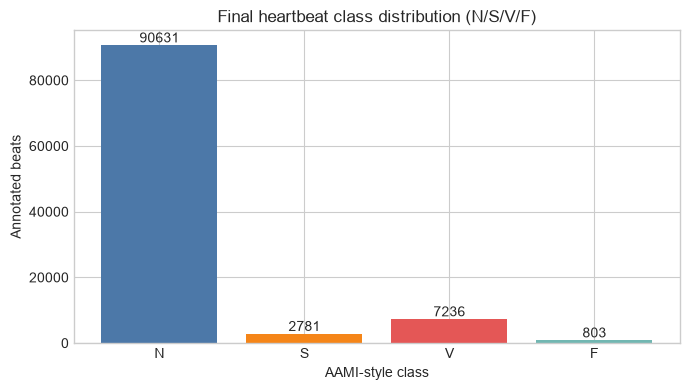

In [10]:
target_annotations = mapped_annotations[
    mapped_annotations["mapped_class"].isin(FINAL_CLASSES)
].copy()

overall_class_counts = (
    target_annotations["mapped_class"]
    .value_counts()
    .reindex(FINAL_CLASSES)
)

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    overall_class_counts.index,
    overall_class_counts.values,
    color=["#4C78A8", "#F58518", "#E45756", "#72B7B2"],
)
ax.bar_label(bars, fmt="%d")
ax.set(
    xlabel="AAMI-style class",
    ylabel="Annotated beats",
    title="Final heartbeat class distribution (N/S/V/F)",
)
fig.tight_layout()
fig.savefig(FIGURES / "figure_02_class_distribution.png", dpi=220)
plt.show()



## 10. Per-Record Class Distribution

Compare within-record class proportions to expose inter-record heterogeneity and minority concentration.

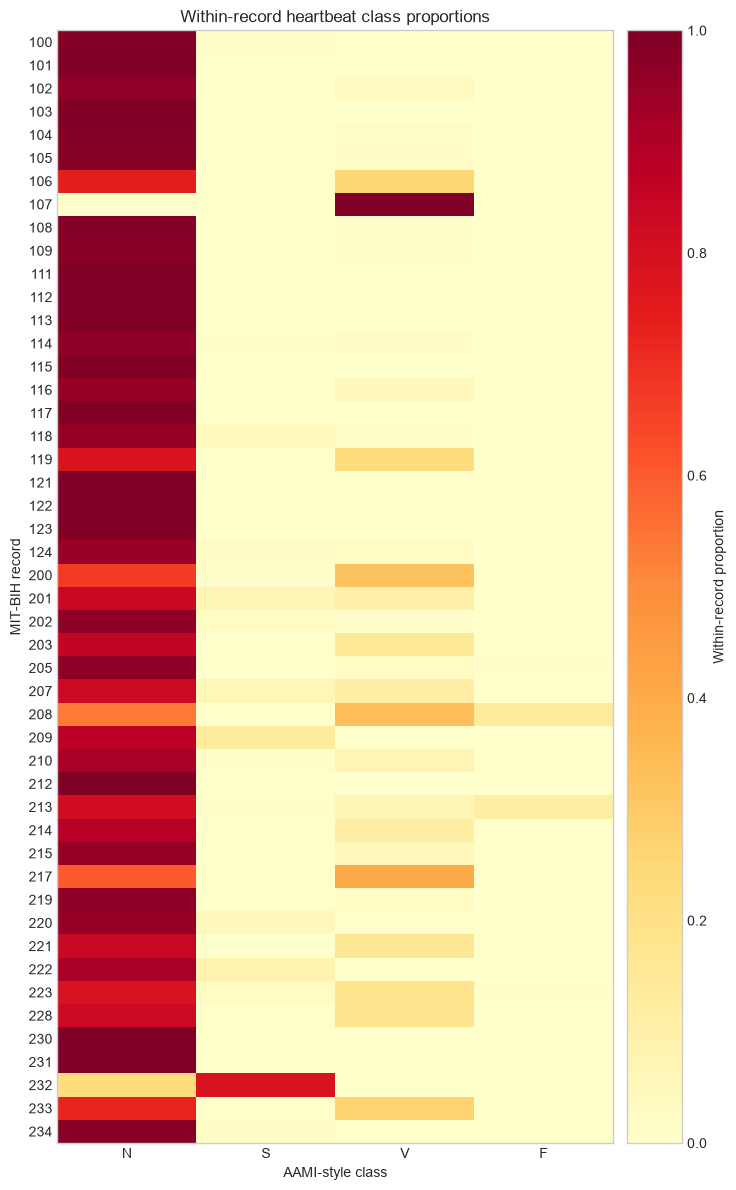

mapped_class,N,S,V,F
record_id,,,,
100,2239,33,1,0
101,1860,3,0,0
102,99,0,4,0
103,2082,2,0,0
104,163,0,2,0
105,2526,0,41,0
106,1507,0,520,0
107,0,0,59,0
108,1740,4,17,2


Records 208 and 213 contain 735 of 803 mapped F annotations.


In [11]:
record_class_counts = (
    target_annotations
    .groupby(["record_id", "mapped_class"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=records, columns=FINAL_CLASSES, fill_value=0)
)
record_class_proportions = record_class_counts.div(
    record_class_counts.sum(axis=1),
    axis=0,
)

fig, ax = plt.subplots(figsize=(7.5, 12))
heatmap = ax.imshow(
    record_class_proportions.to_numpy(),
    aspect="auto",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
)
ax.grid(False)
ax.set_xticks(range(len(FINAL_CLASSES)), labels=FINAL_CLASSES)
ax.set_yticks(range(len(records)), labels=records)
ax.set(
    xlabel="AAMI-style class",
    ylabel="MIT-BIH record",
    title="Within-record heartbeat class proportions",
)
colorbar = fig.colorbar(heatmap, ax=ax, pad=0.02)
colorbar.set_label("Within-record proportion")
fig.tight_layout()
fig.savefig(FIGURES / "eda_record_class_distribution.png", dpi=220)
plt.show()

f_by_record = record_class_counts["F"].sort_values(ascending=False)
top_two_f = int(f_by_record.loc[["208", "213"]].sum())
total_f = int(f_by_record.sum())
display(record_class_counts)
print(f"Records 208 and 213 contain {top_two_f} of {total_f} mapped F annotations.")


N dominates most records, while S and V proportions vary substantially between recordings. F is particularly concentrated: records 208 and 213 contain 735 of the database's 803 mapped F annotations. This record dependence supports patient/record-level splitting; a random beat-level split could place highly related recording context in both training and testing and produce an overly optimistic evaluation. The figure is descriptive and does not establish that composition alone causes later model errors.


## 11. Representative Heartbeat Morphology

Inspect a raw annotated segment and class-specific median/IQR waveforms without duplicating Notebook 02 preprocessing.

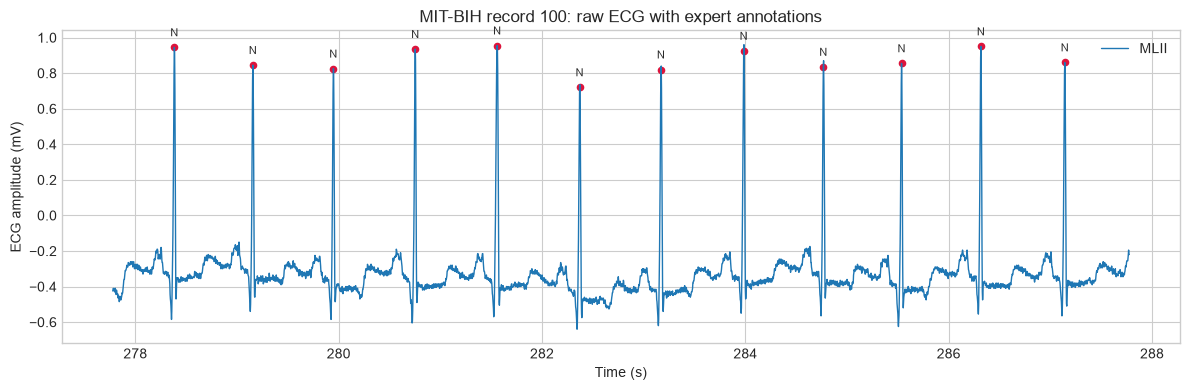

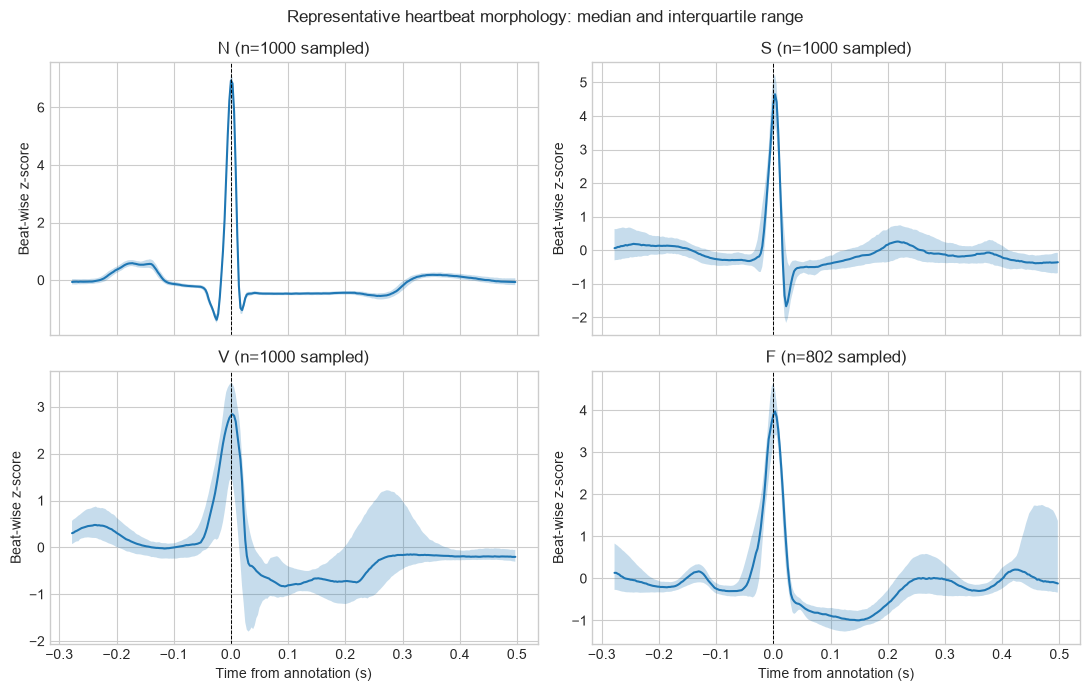

In [12]:
# Figure 1: a genuine 10-second excerpt with expert reference annotations.
example_id = "100"
example_record = headers[example_id]
example_annotation = annotations[example_id]
selection_by_record = channel_selection.set_index("record_id")
selected_index = int(selection_by_record.loc[example_id, "selected_channel_index"])

start = 100000
stop = start + 10 * int(example_record.fs)
annotation_mask = (
    (example_annotation.sample >= start)
    & (example_annotation.sample < stop)
)
time_seconds = np.arange(start, stop) / example_record.fs

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    time_seconds,
    example_record.p_signal[start:stop, selected_index],
    linewidth=1,
    label=example_record.sig_name[selected_index],
)
visible_samples = example_annotation.sample[annotation_mask]
visible_symbols = np.asarray(example_annotation.symbol)[annotation_mask]
for sample, symbol in zip(visible_samples, visible_symbols):
    amplitude = example_record.p_signal[sample, selected_index]
    ax.scatter(sample / example_record.fs, amplitude, color="crimson", s=20)
    ax.annotate(
        symbol,
        (sample / example_record.fs, amplitude),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )
ax.set(
    xlabel="Time (s)",
    ylabel="ECG amplitude (mV)",
    title="MIT-BIH record 100: raw ECG with expert annotations",
)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "figure_01_raw_ecg_annotations.png", dpi=220)
plt.show()

# Figure 3 uses deterministic first-occurring samples only for descriptive morphology.
PRE_SAMPLES = 100
POST_SAMPLES = 180
MAX_EXAMPLES_PER_CLASS = 1000
waveforms_by_class = {class_name: [] for class_name in FINAL_CLASSES}

for record_id in records:
    record = headers[record_id]
    annotation = annotations[record_id]
    selected_index = int(selection_by_record.loc[record_id, "selected_channel_index"])

    for sample, symbol in zip(annotation.sample, annotation.symbol):
        class_name = AAMI_MAP.get(symbol)
        has_complete_window = (
            PRE_SAMPLES <= sample < record.sig_len - POST_SAMPLES
        )
        needs_more_examples = (
            class_name in FINAL_CLASSES
            and len(waveforms_by_class[class_name]) < MAX_EXAMPLES_PER_CLASS
        )
        if not (has_complete_window and needs_more_examples):
            continue

        waveform = record.p_signal[
            sample - PRE_SAMPLES:sample + POST_SAMPLES,
            selected_index,
        ].astype(float)
        standard_deviation = waveform.std()
        denominator = standard_deviation if standard_deviation > 1e-8 else 1.0
        standardised_waveform = (waveform - waveform.mean()) / denominator
        waveforms_by_class[class_name].append(standardised_waveform)

relative_time = (
    np.arange(PRE_SAMPLES + POST_SAMPLES) - PRE_SAMPLES
) / 360
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, class_name in zip(axes.ravel(), FINAL_CLASSES):
    waveforms = np.asarray(waveforms_by_class[class_name])
    median_waveform = np.median(waveforms, axis=0)
    lower_quartile, upper_quartile = np.percentile(
        waveforms,
        [25, 75],
        axis=0,
    )
    ax.plot(relative_time, median_waveform, linewidth=1.5)
    ax.fill_between(relative_time, lower_quartile, upper_quartile, alpha=0.25)
    ax.axvline(0, color="black", linestyle="--", linewidth=0.7)
    ax.set_title(f"{class_name} (n={len(waveforms)} sampled)")
    ax.set_ylabel("Beat-wise z-score")
for ax in axes[-1]:
    ax.set_xlabel("Time from annotation (s)")
fig.suptitle("Representative heartbeat morphology: median and interquartile range")
fig.tight_layout()
fig.savefig(FIGURES / "figure_03_representative_waveforms.png", dpi=220)
plt.show()


## 12. RR-Interval Exploration

Calculate previous RR intervals strictly within each record and summarise them by current-beat class.

,count,median_rr_seconds,q1_seconds,q3_seconds,iqr_seconds,mean_rr_seconds,std_rr_seconds
mapped_class,,,,,,,
N,90588,0.769444,0.672222,0.922222,0.250000,0.837644,0.946099
S,2781,0.677778,0.488889,0.733333,0.244444,0.615849,0.141433
V,7232,0.513889,0.452778,0.563889,0.111111,1.104562,12.302828
F,802,0.563889,0.550000,0.591667,0.041667,0.584338,0.103386


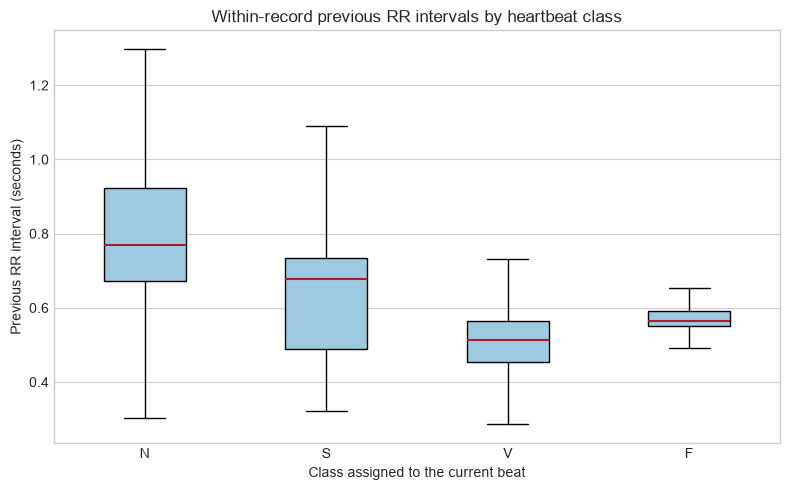

In [13]:
# RR differences are calculated only between consecutive eligible beats in one record.
rr_rows = []
for record_id in records:
    record = headers[record_id]
    annotation = annotations[record_id]

    eligible_beats = [
        (int(sample), AAMI_MAP[symbol])
        for sample, symbol in zip(annotation.sample, annotation.symbol)
        if AAMI_MAP.get(symbol) in FINAL_CLASSES
    ]

    for beat_index in range(1, len(eligible_beats)):
        previous_sample = eligible_beats[beat_index - 1][0]
        current_sample, current_class = eligible_beats[beat_index]
        rr_seconds = (current_sample - previous_sample) / record.fs
        rr_rows.append({
            "record_id": record_id,
            "mapped_class": current_class,
            "rr_seconds": rr_seconds,
        })

rr_intervals = pd.DataFrame(rr_rows)
assert (rr_intervals["rr_seconds"] > 0).all()

rr_summary = (
    rr_intervals
    .groupby("mapped_class")["rr_seconds"]
    .agg(
        count="size",
        median_rr_seconds="median",
        q1_seconds=lambda values: values.quantile(0.25),
        q3_seconds=lambda values: values.quantile(0.75),
        mean_rr_seconds="mean",
        std_rr_seconds="std",
    )
    .reindex(FINAL_CLASSES)
)
rr_summary["iqr_seconds"] = (
    rr_summary["q3_seconds"] - rr_summary["q1_seconds"]
)
rr_summary = rr_summary[
    [
        "count",
        "median_rr_seconds",
        "q1_seconds",
        "q3_seconds",
        "iqr_seconds",
        "mean_rr_seconds",
        "std_rr_seconds",
    ]
]
display(rr_summary)

rr_values_by_class = [
    rr_intervals.loc[
        rr_intervals["mapped_class"] == class_name,
        "rr_seconds",
    ].to_numpy()
    for class_name in FINAL_CLASSES
]
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    rr_values_by_class,
    tick_labels=FINAL_CLASSES,
    showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": "#9ecae1"},
    medianprops={"color": "#b2182b", "linewidth": 1.5},
)
ax.grid(axis="x", visible=False)
ax.set(
    xlabel="Class assigned to the current beat",
    ylabel="Previous RR interval (seconds)",
    title="Within-record previous RR intervals by heartbeat class",
)
fig.tight_layout()
fig.savefig(FIGURES / "eda_rr_interval_by_class.png", dpi=220)
plt.show()


The boxplot hides individual outlier markers for readability but does not remove any valid interval from the full-data summary table. Rare long intervals make the means and standard deviations, particularly for V, much more tail-sensitive than the medians and IQRs; robust summaries are therefore emphasised. Differences in the medians and spreads show that rhythm context varies by the class assigned to the current beat. This motivates later engineered features such as previous RR, next RR, local mean RR, relative RR, and RR deviation; RR alone is not treated as diagnostic or causal evidence. Later Random Forest permutation importance provides separate model-based evidence about whether those pre-specified rhythm features were useful.


## 13. Dataset Sampling Design

Document the authoritative random and arrhythmia-enriched record groups.

In [14]:
# Membership is taken from the bundled official MIT-BIH directory, not guessed.
random_sample_records = [
    "100", "101", "102", "103", "104", "105", "106", "107", "108",
    "109", "111", "112", "113", "114", "115", "116", "117", "118",
    "119", "121", "122", "123", "124",
]
enriched_sample_records = [
    "200", "201", "202", "203", "205", "207", "208", "209", "210",
    "212", "213", "214", "215", "217", "219", "220", "221", "222",
    "223", "228", "230", "231", "232", "233", "234",
]
assert len(random_sample_records) == 23
assert len(enriched_sample_records) == 25
assert set(random_sample_records + enriched_sample_records) == set(records)

sampling_groups = {
    record_id: "random" for record_id in random_sample_records
}
sampling_groups.update({
    record_id: "arrhythmia_enriched"
    for record_id in enriched_sample_records
})

sampling_context = record_class_counts.copy()
sampling_context["sampling_group"] = sampling_context.index.map(sampling_groups)
sampling_summary = (
    sampling_context
    .groupby("sampling_group")
    .agg(
        records=("sampling_group", "size"),
        N=("N", "sum"),
        S=("S", "sum"),
        V=("V", "sum"),
        F=("F", "sum"),
    )
)
display(sampling_summary)


,records,N,S,V,F
sampling_group,,,,,
arrhythmia_enriched,25,50768,2589,5890,790
random,23,39863,192,1346,13


Official MIT-BIH documentation identifies 23 randomly selected recordings and 25 recordings deliberately selected to include less common, clinically important arrhythmias. Consequently, aggregate MIT-BIH class proportions should not be interpreted as real-world arrhythmia or disease prevalence.


## 14. Patient/Record-Independent Split

Present the exact split selected before training and fixed for all experiments.

In [15]:
# These lists were fixed before model training and are now experiment invariants.
train_records = [
    "100", "103", "104", "105", "106", "109", "111", "112",
    "113", "115", "116", "117", "118", "119", "121", "122",
    "123", "124", "200", "203", "205", "207", "208", "212",
    "214", "215", "222", "223", "228", "230", "232", "234",
]
validation_records = [
    "107", "108", "201", "202", "213", "220", "221", "231",
]
test_records = [
    "101", "102", "114", "209", "210", "217", "219", "233",
]

# Stop rather than silently overwrite if the locked repository lists ever differ.
locked_split_files = {
    "train": PROCESSED / "train_records.txt",
    "validation": PROCESSED / "validation_records.txt",
    "test": PROCESSED / "test_records.txt",
}
split_record_lists = {
    "train": train_records,
    "validation": validation_records,
    "test": test_records,
}
for split_name, split_path in locked_split_files.items():
    saved_records = split_path.read_text().split()
    expected_records = split_record_lists[split_name]
    assert saved_records == expected_records, (
        f"Locked {split_name} records differ from the established experiment."
    )

train_set = set(train_records)
validation_set = set(validation_records)
test_set = set(test_records)
assert train_set.isdisjoint(validation_set)
assert train_set.isdisjoint(test_set)
assert validation_set.isdisjoint(test_set)
assert {"201", "202"}.issubset(validation_set)
assert train_set | validation_set | test_set == set(records)

split_rows = []
for split_name, record_ids in split_record_lists.items():
    class_counts = record_class_counts.loc[record_ids].sum()
    total_beats = int(class_counts.sum())
    row = {
        "split": split_name,
        "records": len(record_ids),
        "beats": total_beats,
    }
    for class_name in FINAL_CLASSES:
        row[class_name] = int(class_counts[class_name])
        row[f"{class_name}_pct"] = (
            100 * class_counts[class_name] / total_beats
        )
    split_rows.append(row)

split_summary = pd.DataFrame(split_rows)
split_summary.to_csv(PROCESSED / "split_class_summary.csv", index=False)
display(split_summary)
print("Train:", train_records)
print("Validation:", validation_records)
print("Test:", test_records)


,split,records,beats,N,N_pct,S,S_pct,V,V_pct,F,F_pct
0,train,32,71094,63622,89.489971,2037,2.865221,5025,7.068107,410,0.576701
1,validation,8,15218,13630,89.564989,310,2.037061,911,5.986332,367,2.411618
2,test,8,15139,13379,88.374397,434,2.866768,1300,8.587093,26,0.171742


Train: ['100', '103', '104', '105', '106', '109', '111', '112', '113', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '203', '205', '207', '208', '212', '214', '215', '222', '223', '228', '230', '232', '234']
Validation: ['107', '108', '201', '202', '213', '220', '221', '231']
Test: ['101', '102', '114', '209', '210', '217', '219', '233']


Splitting occurs at record/subject level so beats from one recording context cannot appear in multiple partitions. Records 201 and 202 belong to the same known subject and remain together in validation. Minority-class coverage was inspected before modelling because F is highly record-concentrated.

The split was originally established by a deterministic search for approximate 70/15/15 partition sizes and viable minority representation, with shared-subject grouping enforced. The search is not rerun here: the exact lists above were fixed before training and used consistently throughout the completed experiment. This avoids presenting split optimisation as a modelling contribution or implying that test results influenced partition selection.


## 15. Split Verification

The displayed assertions verify disjoint partitions, complete record coverage, shared-subject handling, and class representation.

In [16]:
split_checks = pd.DataFrame({
 'Check': ['Train/Validation overlap','Train/Test overlap','Validation/Test overlap','Shared subject 201/202 kept together','All classes represented'],
 'Result': ['PASS' if train_set.isdisjoint(validation_set) else 'FAIL','PASS' if train_set.isdisjoint(test_set) else 'FAIL','PASS' if validation_set.isdisjoint(test_set) else 'FAIL','PASS' if {'201','202'}.issubset(validation_set) else 'FAIL','PASS' if (split_summary[FINAL_CLASSES] > 0).all().all() else 'FAIL'],
})
display(split_checks)
assert split_checks['Result'].eq('PASS').all()

,Check,Result
0,Train/Validation overlap,PASS
1,Train/Test overlap,PASS
2,Validation/Test overlap,PASS
3,Shared subject 201/202 kept together,PASS
4,All classes represented,PASS


## 16. Report-Ready Tables

Fifteen formatted one-sheet Excel tables are exported under `report/tables/`, covering dataset, channels, annotations, mapping, viability, distributions, sampling, split decisions, and the Stage 1 summary. These are presentation copies only and do not replace processed CSVs.

## 17. Stage 1 Summary

The locked audit establishes genuine data provenance, the four-class target, lead exceptions, record heterogeneity, and patient-independent evaluation.

## 10. Stage 1 conclusions

- All 48 genuine MIT-BIH records load at 360 Hz without missing or infinite signal values.
- MLII is used for 46 records; records 102 and 104 use V5 as documented lead exceptions.
- The fixed target is N/S/V/F after auditing and excluding Q for independent-record viability.
- Severe overall imbalance is accompanied by substantial record-level heterogeneity, especially F concentration.
- Within-record RR distributions differ descriptively across classes and motivate rhythm-context features without making a diagnostic claim.
- The database combines random and arrhythmia-enriched samples, so its aggregate class proportions are not population prevalence.
- The locked patient-independent split preserves records 201/202 together and prevents record-level leakage.


In [17]:
required_outputs = [
    FIGURES / "figure_01_raw_ecg_annotations.png",
    FIGURES / "figure_02_class_distribution.png",
    FIGURES / "figure_03_representative_waveforms.png",
    FIGURES / "eda_record_class_distribution.png",
    FIGURES / "eda_rr_interval_by_class.png",
    PROCESSED / "record_audit.csv",
    PROCESSED / "channel_selection.csv",
    PROCESSED / "split_class_summary.csv",
]
assert all(path.exists() and path.stat().st_size > 0 for path in required_outputs)
print("EDA integrity checks passed; all required tables, splits, and figures exist.")


EDA integrity checks passed; all required tables, splits, and figures exist.
